# Обнаружение аномалий во временных рядах — методы без учителя

**Датасет:** еженедельное энергопотребление, ветровая и солнечная генерация (Германия)  
**Цель:** реализовать и сравнить несколько методов детекции аномалий  
**Бейслайн:** уже готов — MSTL + доверительный интервал 99%

---
### Структура ноутбука
1. Загрузка данных и воспроизведение бейслайна (MSTL)
2. Feature engineering
3. Метод 1 — Rolling Z-score (статистика)
4. Метод 2 — STL decomposition + пороговый остаток
5. Метод 3 — Isolation Forest (ML)
6. Метод 4 — One-Class SVM (ML)
7. Метод 5 — LSTM Autoencoder (Deep Learning, бонус)
8. Сравнение методов и ансамблирование
9. Визуализация итогов

## 0. Установка зависимостей

## 1. Загрузка данных и бейслайн (MSTL)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ---------- загрузка ----------
df = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)

# ---------- недельная агрегация ----------
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind':        'sum',
    'Solar':       'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]   # убираем краевые артефакты
print(f"Размер датасета: {y.shape}")
print(f"Период: {y.index[0].date()} → {y.index[-1].date()}")
y.head(3)

Размер датасета: (259, 5)
Период: 2015-01-11 → 2019-12-22


,Consumption,Wind,Solar,temperature,radiation_direct_horizontal
time,,,,,
2015-01-11,9440.105,2908.073,132.229,2.488536,5.554645
2015-01-18,9689.010,2621.273,172.051,3.012375,7.504608
2015-01-25,9847.035,468.337,97.130,-1.319012,10.306792


In [3]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL

ts       = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']
FREQ     = y.index.freq
SEASON   = 52
FH       = int(0.42 * y.shape[0])

# ---------- panel format ----------
date_index = y.index
panel_list = [
    pd.DataFrame({'ds': date_index, 'y': y[t].values, 'unique_id': t})
    for t in ts
]
panel_df = pd.concat(panel_list, ignore_index=True)[base_cols]

df_test  = panel_df.groupby("unique_id").tail(FH)
df_train = panel_df.drop(df_test.index).reset_index(drop=True)

# ---------- MSTL ----------
models = [MSTL(season_length=[SEASON], alias='MSTL')]
sf = StatsForecast(models=models, freq=FREQ)

fcst               = sf.forecast(df=df_train, h=FH, level=[99], fitted=True)
insample_forecasts = sf.forecast_fitted_values().drop(columns=['y'])

res_df = panel_df.merge(
    pd.concat([insample_forecasts, fcst]),
    on=['unique_id', 'ds'], how='left'
)

# ---------- MSTL аномалии (бейслайн) ----------
mask_mstl  = ~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])
anomalies_mstl = res_df[mask_mstl][['unique_id','ds','y']].copy()
anomalies_mstl['MSTL_anomaly'] = 1

print(f"MSTL нашёл аномалий: {len(anomalies_mstl)}")
anomalies_mstl.groupby('unique_id').size()

MSTL нашёл аномалий: 41


unique_id
Consumption    11
Solar          22
Wind            8
dtype: int64

## 2. Feature Engineering

Для ML-методов нужно превратить временной ряд в матрицу признаков.  
Типичный набор для задачи аномалий:

| Признак | Смысл |
|---|---|
| `lag_1`, `lag_4`, `lag_52` | значение 1, 4, 52 недели назад |
| `roll_mean_4`, `roll_std_4` | скользящее среднее и std за 4 нед. |
| `roll_mean_13`, `roll_std_13` | то же за 13 нед. (квартал) |
| `diff_1` | первая разность (изменение за неделю) |
| `week`, `month` | циклические временные признаки |

In [4]:
from sklearn.preprocessing import RobustScaler

def make_features(series: pd.Series) -> pd.DataFrame:
    """Создаёт матрицу признаков для одного временного ряда."""
    df = pd.DataFrame({'y': series.values}, index=series.index)

    # лаги
    for lag in [1, 4, 13, 52]:
        df[f'lag_{lag}'] = df['y'].shift(lag)

    # скользящие статистики
    for w in [4, 13]:
        df[f'roll_mean_{w}'] = df['y'].shift(1).rolling(w).mean()
        df[f'roll_std_{w}']  = df['y'].shift(1).rolling(w).std()

    # разности
    df['diff_1']  = df['y'].diff(1)
    df['diff_52'] = df['y'].diff(52)   # год к году

    # временные признаки
    df['week']  = df.index.isocalendar().week.astype(int)
    df['month'] = df.index.month

    df.dropna(inplace=True)
    return df

# --- строим для каждого ряда ---
feature_dfs = {}
for col in ts:
    feat = make_features(y[col])
    feature_dfs[col] = feat

print("Признаки:", feature_dfs['Consumption'].columns.tolist())
print("Строк после dropna:", len(feature_dfs['Consumption']))

Признаки: ['y', 'lag_1', 'lag_4', 'lag_13', 'lag_52', 'roll_mean_4', 'roll_std_4', 'roll_mean_13', 'roll_std_13', 'diff_1', 'diff_52', 'week', 'month']
Строк после dropna: 207


## 3. Метод 1 — Rolling Z-score

**Идея:** точка является аномалией, если она далеко отстоит от скользящего среднего в единицах стандартного отклонения.

$$z_t = \frac{y_t - \mu_{t,w}}{\sigma_{t,w}}$$

где $\mu_{t,w}$ и $\sigma_{t,w}$ — скользящие среднее и std по окну $w$ (не включая $y_t$ сам).

**Параметр для настройки:** порог `threshold` (обычно 2.5–3.5).

Consumption: 13 аномалий
Wind: 8 аномалий
Solar: 17 аномалий


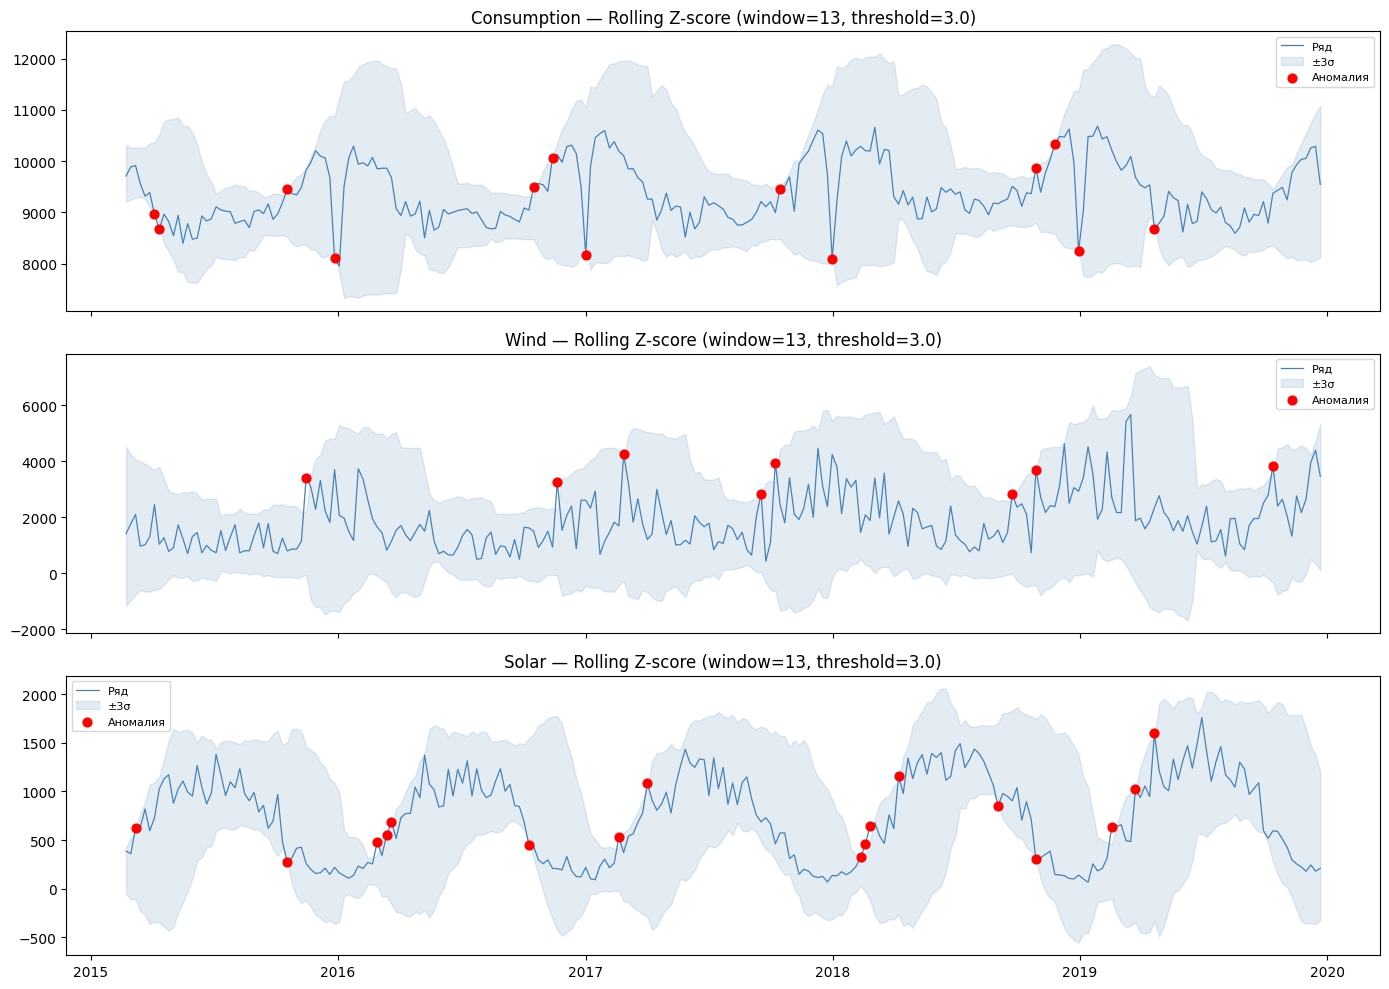

Сохранено: zscore_anomalies.png


In [5]:
def rolling_zscore_anomalies(
    series: pd.Series,
    window: int = 13,
    threshold: float = 3.0
) -> pd.DataFrame:
    """
    Детектор аномалий на основе скользящего z-score.

    Параметры
    ----------
    series    : временной ряд
    window    : ширина скользящего окна (недели)
    threshold : порог по |z-score|

    Возвращает DataFrame с колонками: y, roll_mean, roll_std, z_score, anomaly
    """
    result = pd.DataFrame({'y': series})

    # shift(1) — не используем текущую точку при вычислении статистик
    result['roll_mean'] = series.shift(1).rolling(window, min_periods=window//2).mean()
    result['roll_std']  = series.shift(1).rolling(window, min_periods=window//2).std()

    result['z_score'] = (result['y'] - result['roll_mean']) / result['roll_std']
    result['anomaly'] = (result['z_score'].abs() > threshold).astype(int)

    return result.dropna()


# --- применяем к каждому ряду ---
zscore_results = {}
for col in ts:
    zscore_results[col] = rolling_zscore_anomalies(y[col], window=13, threshold=3.0)
    n = zscore_results[col]['anomaly'].sum()
    print(f"{col}: {n} аномалий")

# --- визуализация ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, ts):
    r = zscore_results[col]
    ax.plot(r.index, r['y'], lw=0.9, label='Ряд', color='steelblue')
    ax.fill_between(
        r.index,
        r['roll_mean'] - 3 * r['roll_std'],
        r['roll_mean'] + 3 * r['roll_std'],
        alpha=0.15, color='steelblue', label='±3σ'
    )
    anom = r[r['anomaly'] == 1]
    ax.scatter(anom.index, anom['y'], color='red', zorder=5, s=40, label='Аномалия')
    ax.set_title(f'{col} — Rolling Z-score (window=13, threshold=3.0)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('zscore_anomalies.png', dpi=120)
plt.show()
print("Сохранено: zscore_anomalies.png")

In [6]:
# Посмотреть конкретные аномальные точки для Consumption
r = zscore_results['Consumption']
anom = r[r['anomaly'] == 1][['y', 'roll_mean', 'z_score']].copy()
anom['отклонение_%'] = ((anom['y'] - anom['roll_mean']) / anom['roll_mean'] * 100).round(1)
anom.sort_values('z_score', key=abs, ascending=False).head(10)

,y,roll_mean,z_score,отклонение_%
time,,,,
2016-10-16,9490.690,8895.185538,4.302251,6.7
2018-10-28,9859.032,9247.260385,4.131047,6.6
2017-01-01,8179.334,9735.902308,-3.555244,-16.0
2015-10-18,9448.987,8957.213231,3.398999,5.5
2015-12-27,8106.565,9579.124923,-3.380291,-15.4
2015-04-12,8669.688,9640.337923,-3.313498,-10.1
2019-04-21,8678.252,10026.985923,-3.306270,-13.5
2015-04-05,8966.120,9696.522750,-3.304831,-7.5
2018-12-30,8244.698,9865.364385,-3.218112,-16.4


## 4. Метод 2 — STL decomposition + пороговый остаток

**Идея:** разложить ряд на три компонента:
$$y_t = T_t + S_t + R_t$$
где $T$ — тренд, $S$ — сезонность, $R$ — остаток.  
Аномалия — это точка, где остаток $|R_t|$ очень большой.

**Преимущество перед z-score:** STL корректно учитывает сезонность, поэтому летние пики Solar не будут флагом.

In [7]:
from statsmodels.tsa.seasonal import STL

def stl_anomalies(
    series: pd.Series,
    period: int = 52,
    threshold_iqr: float = 3.0
) -> pd.DataFrame:
    """
    Аномалии через STL-разложение.

    Параметры
    ----------
    series        : временной ряд
    period        : сезонный период (52 для недельных данных)
    threshold_iqr : порог в единицах IQR остатка
                    (3.0 ≈ аналог 3σ для нормального распределения)
    """
    stl = STL(series, period=period, robust=True)
    res = stl.fit()

    residual = res.resid

    # IQR-порог (устойчивее к выбросам, чем std)
    q1, q3 = residual.quantile(0.25), residual.quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - threshold_iqr * iqr
    upper  = q3 + threshold_iqr * iqr

    result = pd.DataFrame({
        'y':        series,
        'trend':    res.trend,
        'seasonal': res.seasonal,
        'residual': residual,
        'anomaly':  ((residual < lower) | (residual > upper)).astype(int)
    })
    result['lower'] = lower
    result['upper'] = upper
    return result


stl_results = {}
for col in ts:
    stl_results[col] = stl_anomalies(y[col], period=52, threshold_iqr=3.0)
    n = stl_results[col]['anomaly'].sum()
    print(f"{col}: {n} аномалий")

Consumption: 16 аномалий
Wind: 27 аномалий
Solar: 42 аномалий


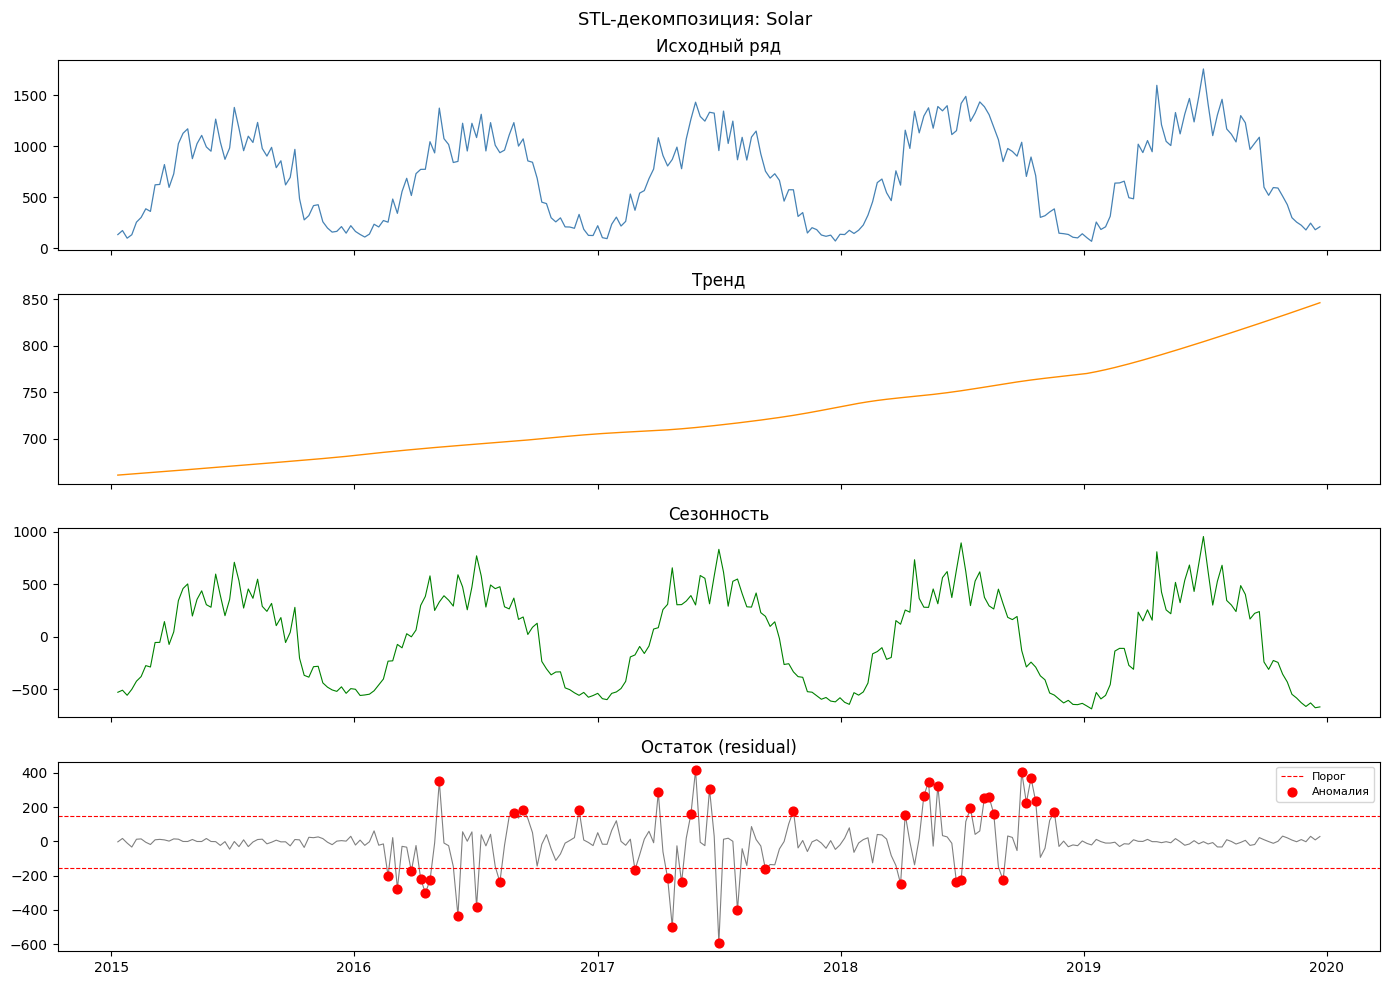

In [8]:
# Визуализация декомпозиции + остатка для одного ряда
col = 'Solar'
r   = stl_results[col]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(r.index, r['y'],        color='steelblue', lw=0.9)
axes[0].set_title('Исходный ряд')

axes[1].plot(r.index, r['trend'],    color='darkorange', lw=1)
axes[1].set_title('Тренд')

axes[2].plot(r.index, r['seasonal'], color='green', lw=0.8)
axes[2].set_title('Сезонность')

axes[3].plot(r.index, r['residual'], color='gray', lw=0.8)
axes[3].axhline(r['upper'].iloc[0], color='red',  ls='--', lw=0.8, label='Порог')
axes[3].axhline(r['lower'].iloc[0], color='red',  ls='--', lw=0.8)
anom = r[r['anomaly'] == 1]
axes[3].scatter(anom.index, anom['residual'], color='red', zorder=5, s=40, label='Аномалия')
axes[3].set_title('Остаток (residual)')
axes[3].legend(fontsize=8)

fig.suptitle(f'STL-декомпозиция: {col}', fontsize=13)
plt.tight_layout()
plt.savefig('stl_decomposition.png', dpi=120)
plt.show()

## 5. Метод 3 — Isolation Forest

**Идея:** строит ансамбль случайных деревьев. Аномальные точки «изолируются» раньше нормальных, потому что они редкие и отличаются от остальных.  

**Ключевой параметр:** `contamination` — ожидаемая доля аномалий в данных (например, 0.03 = 3%).

**Входные данные:** матрица признаков из шага 2 (лаги, rolling stats, diff).

In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

def isolation_forest_anomalies(
    feat_df: pd.DataFrame,
    contamination: float = 0.03,
    random_state: int = 42
) -> pd.Series:
    """
    Детектор аномалий через Isolation Forest.

    Параметры
    ----------
    feat_df       : DataFrame признаков (выход make_features)
    contamination : ожидаемая доля аномалий (0.01–0.1)

    Возвращает pd.Series с метками 0/1 (индекс = дата)
    """
    feature_cols = [c for c in feat_df.columns if c != 'y']
    X = feat_df[feature_cols].values

    # нормализация (IsolationForest не требует, но улучшает стабильность)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    clf = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=random_state
    )
    # predict возвращает +1 (норма) или -1 (аномалия)
    preds = clf.fit_predict(X_scaled)
    labels = (preds == -1).astype(int)

    # anomaly score (чем ниже, тем аномальнее)
    scores = clf.decision_function(X_scaled)

    result = pd.Series(labels, index=feat_df.index, name='anomaly')
    return result, pd.Series(scores, index=feat_df.index, name='score')


iforest_results = {}
for col in ts:
    labels, scores = isolation_forest_anomalies(feature_dfs[col], contamination=0.03)
    iforest_results[col] = pd.DataFrame({'y': feature_dfs[col]['y'], 'anomaly': labels, 'score': scores})
    print(f"{col}: {labels.sum()} аномалий")

Consumption: 7 аномалий
Wind: 7 аномалий
Solar: 7 аномалий


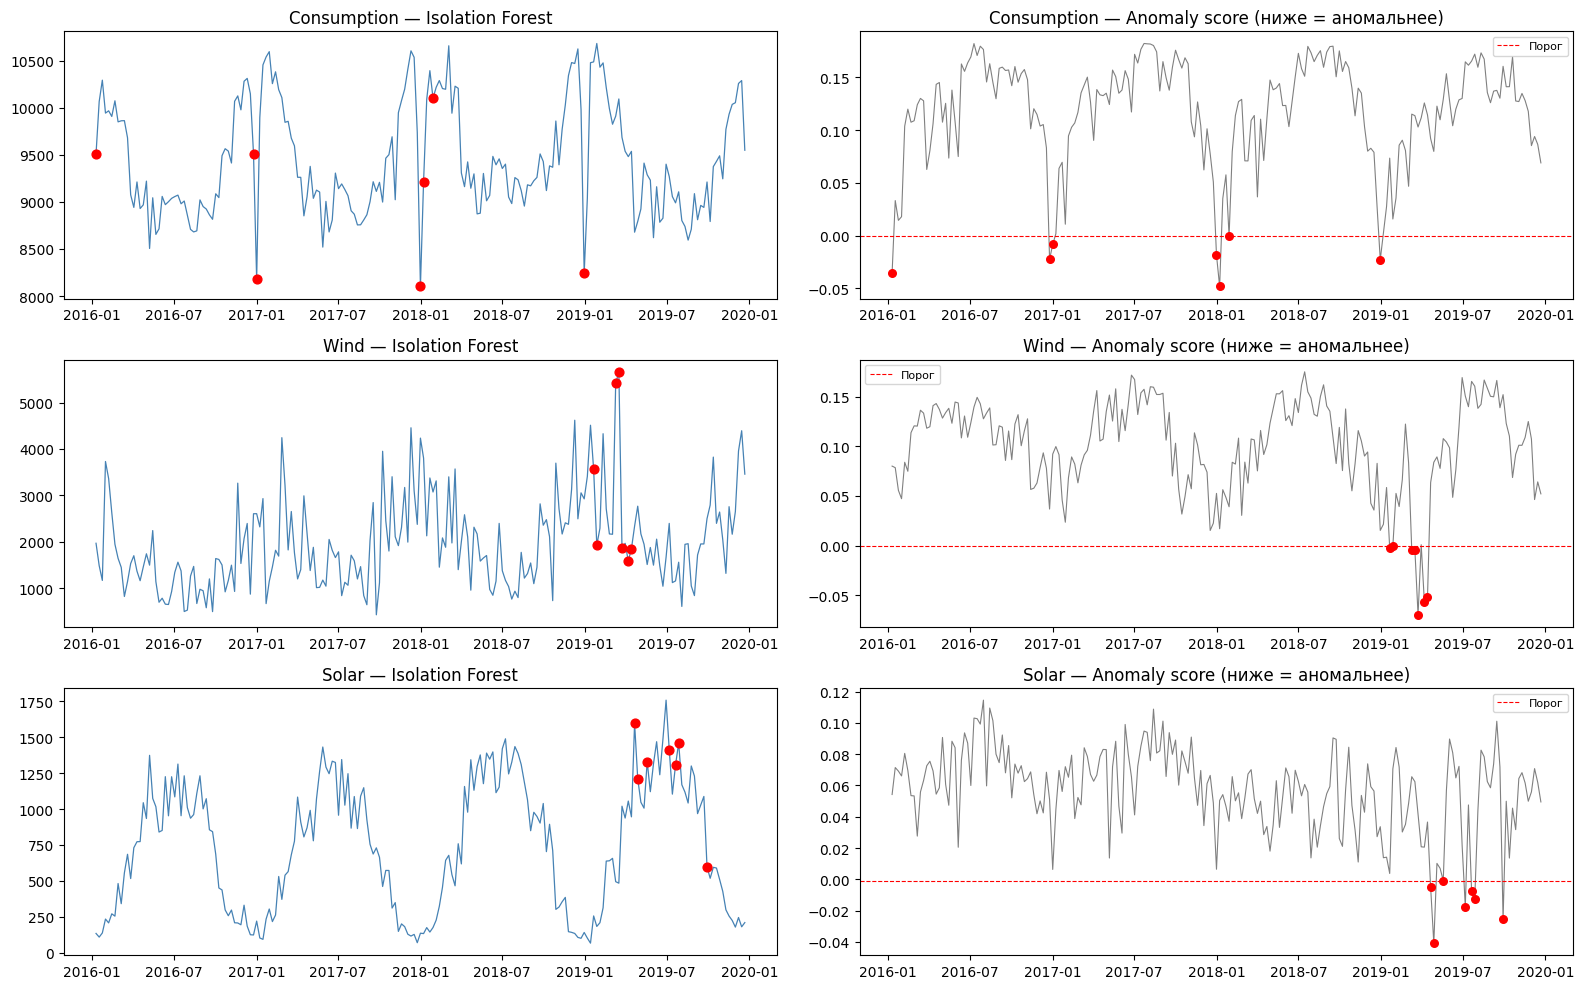

In [10]:
# Визуализация: ряд + anomaly score
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, col in enumerate(ts):
    r = iforest_results[col]

    # левая колонка — ряд с аномалиями
    ax = axes[i][0]
    ax.plot(r.index, r['y'], lw=0.9, color='steelblue')
    anom = r[r['anomaly'] == 1]
    ax.scatter(anom.index, anom['y'], color='red', zorder=5, s=40)
    ax.set_title(f'{col} — Isolation Forest')

    # правая колонка — anomaly score
    ax2 = axes[i][1]
    ax2.plot(r.index, r['score'], lw=0.8, color='gray')
    ax2.axhline(r.loc[r['anomaly']==1, 'score'].max() if anom.shape[0] > 0 else 0,
                color='red', ls='--', lw=0.8, label='Порог')
    ax2.scatter(anom.index, r.loc[anom.index, 'score'], color='red', s=30, zorder=5)
    ax2.set_title(f'{col} — Anomaly score (ниже = аномальнее)')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('iforest_anomalies.png', dpi=120)
plt.show()

## 6. Метод 4 — One-Class SVM

**Идея:** обучаемся только на «нормальных» данных (train), строим гиперплоскость, отделяющую норму от остального пространства.  
Всё что снаружи — аномалия.

**Ключевые параметры:**
- `nu` — верхняя граница доли аномалий (0.01–0.1)
- `kernel` — `'rbf'` (по умолчанию) работает лучше всего для нелинейных данных

In [11]:
from sklearn.svm import OneClassSVM

def one_class_svm_anomalies(
    feat_df: pd.DataFrame,
    train_ratio: float = 0.6,
    nu: float = 0.03,
    kernel: str = 'rbf',
    gamma: str = 'scale'
) -> pd.Series:
    """
    One-Class SVM: обучается на первых train_ratio данных, предсказывает на всех.

    Параметры
    ----------
    feat_df     : DataFrame признаков
    train_ratio : доля начала ряда, считаемая «нормальной» (для обучения)
    nu          : верхняя граница доли опорных векторов-аномалий
    """
    feature_cols = [c for c in feat_df.columns if c != 'y']
    X = feat_df[feature_cols].values

    scaler  = RobustScaler()
    X_sc    = scaler.fit_transform(X)

    # обучаем только на первой части
    n_train = int(len(X_sc) * train_ratio)
    X_train = X_sc[:n_train]

    clf = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    clf.fit(X_train)

    # predict: +1 норма, -1 аномалия
    preds  = clf.predict(X_sc)
    labels = (preds == -1).astype(int)
    scores = clf.decision_function(X_sc)  # < 0 → аномалия

    return (
        pd.Series(labels, index=feat_df.index, name='anomaly'),
        pd.Series(scores, index=feat_df.index, name='score')
    )


ocsvm_results = {}
for col in ts:
    labels, scores = one_class_svm_anomalies(feature_dfs[col], nu=0.03)
    ocsvm_results[col] = pd.DataFrame({'y': feature_dfs[col]['y'], 'anomaly': labels, 'score': scores})
    print(f"{col}: {labels.sum()} аномалий")

Consumption: 42 аномалий
Wind: 40 аномалий
Solar: 64 аномалий


In [12]:
# Сравнение: что нашёл OC-SVM, чего не нашёл IForest (и наоборот)
col = 'Wind'
if  = set(iforest_results[col][iforest_results[col]['anomaly']==1].index)
svm = set(ocsvm_results[col][ocsvm_results[col]['anomaly']==1].index)

print(f"Isolation Forest: {len(if)} аномалий")
print(f"One-Class SVM:    {len(svm)} аномалий")
print(f"Пересечение:      {len(if & svm)}")
print(f"Только IForest:   {len(if - svm)}")
print(f"Только OC-SVM:    {len(svm - if)}")

SyntaxError: invalid syntax (2812380544.py, line 3)

## 7. Метод 5 — LSTM Autoencoder (Deep Learning, бонус)

**Идея:** обучить LSTM на нормальных данных восстанавливать входную последовательность.  
Аномальные точки будут плохо восстанавливаться → высокая ошибка реконструкции → аномалия.

```
[x_t-w, ..., x_t]  →  Encoder (LSTM)  →  скрытое состояние  →  Decoder (LSTM)  →  [x̂_t-w, ..., x̂_t]
```

**Порог:** 95-й или 99-й перцентиль ошибки реконструкции на train.

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ---- модель ----
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc      = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        # x: (batch, seq_len, features)
        _, (h, c)        = self.encoder(x)
        # decoder получает скрытое состояние как начало
        dec_input        = h.permute(1, 0, 2).repeat(1, x.size(1), 1)
        out, _           = self.decoder(dec_input, (h, c))
        reconstructed    = self.fc(out)
        return reconstructed


def create_sequences(data: np.ndarray, seq_len: int) -> np.ndarray:
    """Разбить ряд на последовательности длины seq_len."""
    seqs = []
    for i in range(len(data) - seq_len + 1):
        seqs.append(data[i : i + seq_len])
    return np.array(seqs)


def lstm_ae_anomalies(
    series: pd.Series,
    seq_len: int = 13,
    train_ratio: float = 0.6,
    hidden_size: int = 32,
    n_epochs: int = 30,
    threshold_pct: float = 99.0
) -> pd.DataFrame:
    """
    LSTM Autoencoder детектор аномалий.

    Параметры
    ----------
    series        : временной ряд
    seq_len       : длина входного окна (недели)
    train_ratio   : доля для обучения
    threshold_pct : перцентиль ошибки реконструкции как порог аномалии
    """
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # нормализация
    vals      = series.values.reshape(-1, 1).astype(np.float32)
    scaler    = RobustScaler()
    vals_norm = scaler.fit_transform(vals).flatten()

    # последовательности
    seqs     = create_sequences(vals_norm, seq_len)  # (N, seq_len)
    n_train  = int(len(seqs) * train_ratio)

    X_train  = torch.tensor(seqs[:n_train, :, None]).to(device)
    X_all    = torch.tensor(seqs[:, :, None]).to(device)

    train_ds = TensorDataset(X_train)
    loader   = DataLoader(train_ds, batch_size=16, shuffle=True)

    model    = LSTMAutoencoder(input_size=1, hidden_size=hidden_size).to(device)
    opt      = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn  = nn.MSELoss()

    # обучение
    model.train()
    for epoch in range(n_epochs):
        for (xb,) in loader:
            pred = model(xb)
            loss = loss_fn(pred, xb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}, loss={loss.item():.5f}")

    # ошибка реконструкции на всех данных
    model.eval()
    with torch.no_grad():
        rec   = model(X_all).cpu().numpy().squeeze()
        orig  = X_all.cpu().numpy().squeeze()
    errors = np.mean((rec - orig) ** 2, axis=1)  # MSE по каждой последовательности

    # порог по перцентилю ошибки на train
    threshold = np.percentile(errors[:n_train], threshold_pct)

    # «центр» каждой последовательности — последний элемент
    dates    = series.index[seq_len - 1:]
    anomaly  = (errors > threshold).astype(int)

    return pd.DataFrame({
        'y':       series.values[seq_len - 1:],
        'error':   errors,
        'anomaly': anomaly
    }, index=dates)


print("Обучаем LSTM Autoencoder для Consumption...")
lstm_results = {}
for col in ts:
    print(f"\n--- {col} ---")
    lstm_results[col] = lstm_ae_anomalies(y[col], seq_len=13, n_epochs=30, threshold_pct=99)
    n = lstm_results[col]['anomaly'].sum()
    print(f"  → {n} аномалий")

Обучаем LSTM Autoencoder для Consumption...

--- Consumption ---
  Epoch 10/30, loss=0.36924
  Epoch 20/30, loss=0.18430
  Epoch 30/30, loss=0.04305
  → 7 аномалий

--- Wind ---
  Epoch 10/30, loss=0.27601
  Epoch 20/30, loss=0.22640
  Epoch 30/30, loss=0.10385
  → 20 аномалий

--- Solar ---
  Epoch 10/30, loss=0.07430
  Epoch 20/30, loss=0.02450
  Epoch 30/30, loss=0.02803
  → 25 аномалий


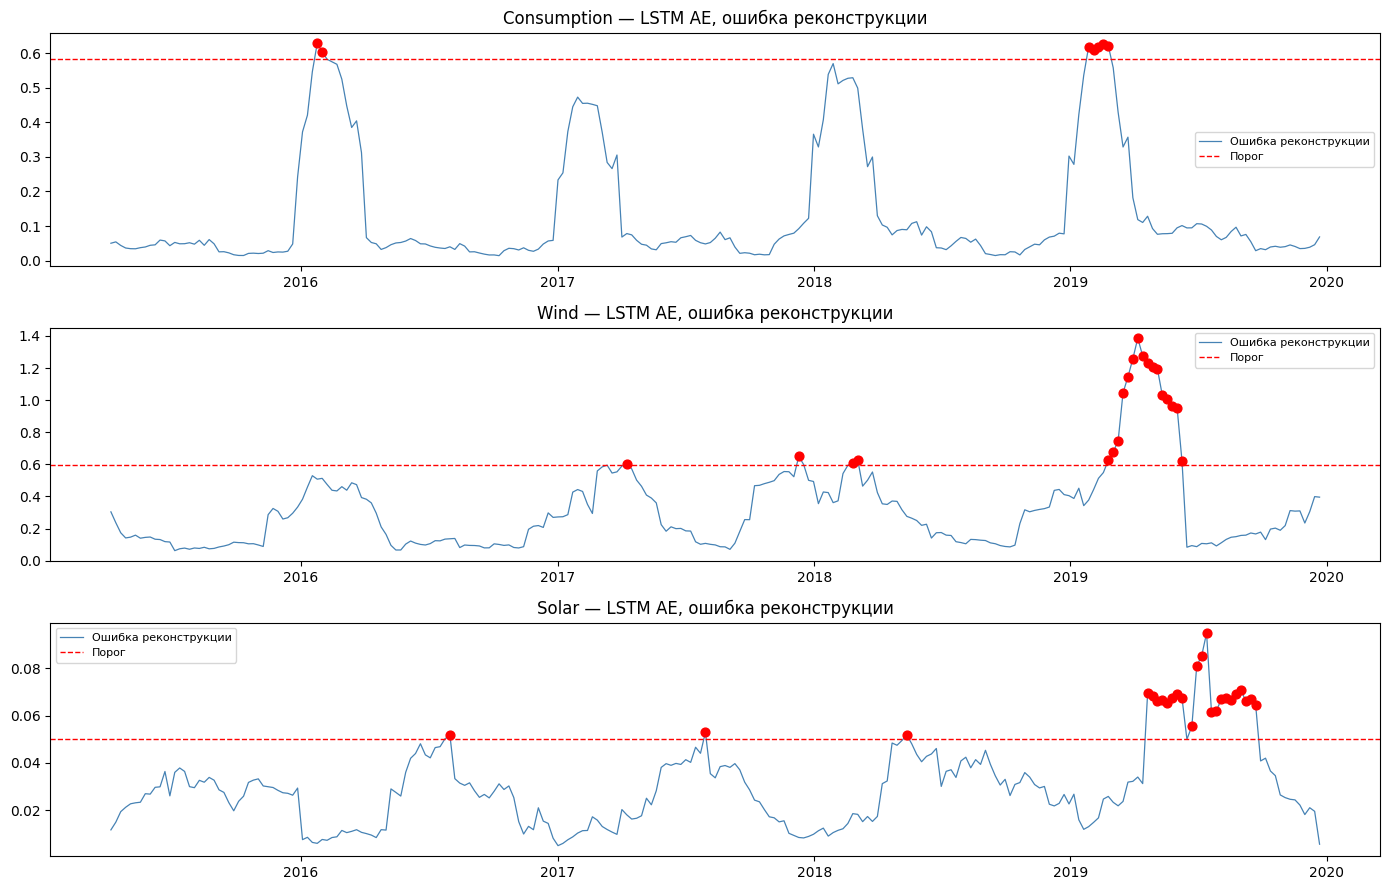

In [14]:
# Визуализация ошибки реконструкции
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
for ax, col in zip(axes, ts):
    r = lstm_results[col]
    ax.plot(r.index, r['error'], lw=0.9, color='steelblue', label='Ошибка реконструкции')
    threshold_val = r.loc[r['anomaly']==0, 'error'].max()
    ax.axhline(threshold_val, color='red', ls='--', lw=1, label='Порог')
    anom = r[r['anomaly'] == 1]
    ax.scatter(anom.index, anom['error'], color='red', zorder=5, s=40)
    ax.set_title(f'{col} — LSTM AE, ошибка реконструкции')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('lstm_ae_errors.png', dpi=120)
plt.show()

## 8. Сравнение методов и ансамблирование

### 8.1 Сводная таблица по каждому ряду

In [15]:
def jaccard(set_a: set, set_b: set) -> float:
    """Коэффициент Жаккара: |A ∩ B| / |A ∪ B|"""
    if not set_a and not set_b:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)


# --- собираем метки всех методов для каждого ряда ---
all_labels = {}   # all_labels[col][method] = pd.Series(0/1, index=dates)

for col in ts:
    idx_full = y.index  # общий индекс

    def to_series(df_or_series, col_name='anomaly'):
        """Привести к pd.Series на полном индексе (заполнить 0)."""
        s = df_or_series[col_name] if isinstance(df_or_series, pd.DataFrame) else df_or_series
        return s.reindex(idx_full, fill_value=0)

    mstl_s = panel_df[panel_df['unique_id']==col].set_index('ds')['y']\
             .index.isin(anomalies_mstl[anomalies_mstl['unique_id']==col]['ds'])
    mstl_series = pd.Series(
        mstl_s.astype(int),
        index=y.index
    )

    all_labels[col] = {
        'MSTL':      mstl_series,
        'ZScore':    to_series(zscore_results[col]),
        'STL':       to_series(stl_results[col]),
        'IForest':   to_series(iforest_results[col]),
        'OC_SVM':    to_series(ocsvm_results[col]),
        'LSTM_AE':   to_series(lstm_results[col]),
    }

# --- таблица сравнения ---
methods = ['MSTL', 'ZScore', 'STL', 'IForest', 'OC_SVM', 'LSTM_AE']

for col in ts:
    print(f"\n{'='*55}")
    print(f"  {col}")
    print(f"{'='*55}")
    print(f"  {'Метод':<12}  {'Аномалий':>9}  {'%':>6}  {'Jaccard с MSTL':>15}")
    print(f"  {'-'*50}")
    n_total = len(y)
    mstl_set = set(y.index[all_labels[col]['MSTL']==1])
    for m in methods:
        s   = all_labels[col][m]
        cnt = s.sum()
        pct = cnt / n_total * 100
        m_set = set(y.index[s==1])
        j = jaccard(mstl_set, m_set)
        print(f"  {m:<12}  {cnt:>9}  {pct:>5.1f}%  {j:>15.3f}")


  Consumption
  Метод          Аномалий       %   Jaccard с MSTL
  --------------------------------------------------
  MSTL                 11    4.2%            1.000
  ZScore               13    5.0%            0.043
  STL                  16    6.2%            0.125
  IForest               7    2.7%            0.125
  OC_SVM               42   16.2%            0.104
  LSTM_AE               7    2.7%            0.000

  Wind
  Метод          Аномалий       %   Jaccard с MSTL
  --------------------------------------------------
  MSTL                  8    3.1%            1.000
  ZScore                8    3.1%            0.231
  STL                  27   10.4%            0.094
  IForest               7    2.7%            0.154
  OC_SVM               40   15.4%            0.091
  LSTM_AE              20    7.7%            0.077

  Solar
  Метод          Аномалий       %   Jaccard с MSTL
  --------------------------------------------------
  MSTL                 22    8.5%           

### 8.2 Ансамблирование: голосование

In [16]:
# Ансамбль: точка = аномалия, если ≥K методов согласны

ensemble_results = {}

for col in ts:
    vote_df = pd.DataFrame(all_labels[col])
    vote_df['votes'] = vote_df.sum(axis=1)

    # K=2: «мягкое» большинство (хотя бы 2 метода)
    vote_df['ensemble_k2'] = (vote_df['votes'] >= 2).astype(int)
    # K=3: «жёсткое» большинство
    vote_df['ensemble_k3'] = (vote_df['votes'] >= 3).astype(int)

    ensemble_results[col] = vote_df

    print(f"{col}: k=2 → {vote_df['ensemble_k2'].sum()} аномалий, "
          f"k=3 → {vote_df['ensemble_k3'].sum()} аномалий")

Consumption: k=2 → 22 аномалий, k=3 → 5 аномалий
Wind: k=2 → 28 аномалий, k=3 → 9 аномалий
Solar: k=2 → 44 аномалий, k=3 → 18 аномалий


## 9. Итоговая визуализация

Для каждого ряда — один график с наложенными метками всех методов.

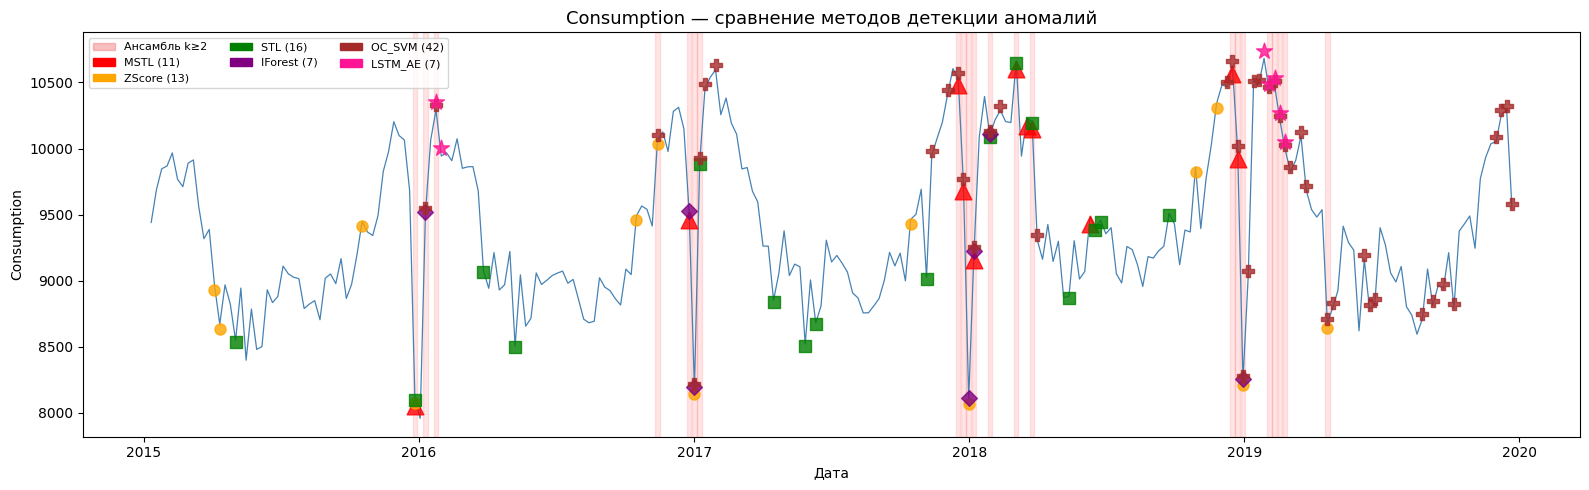

Сохранено: comparison_consumption.png


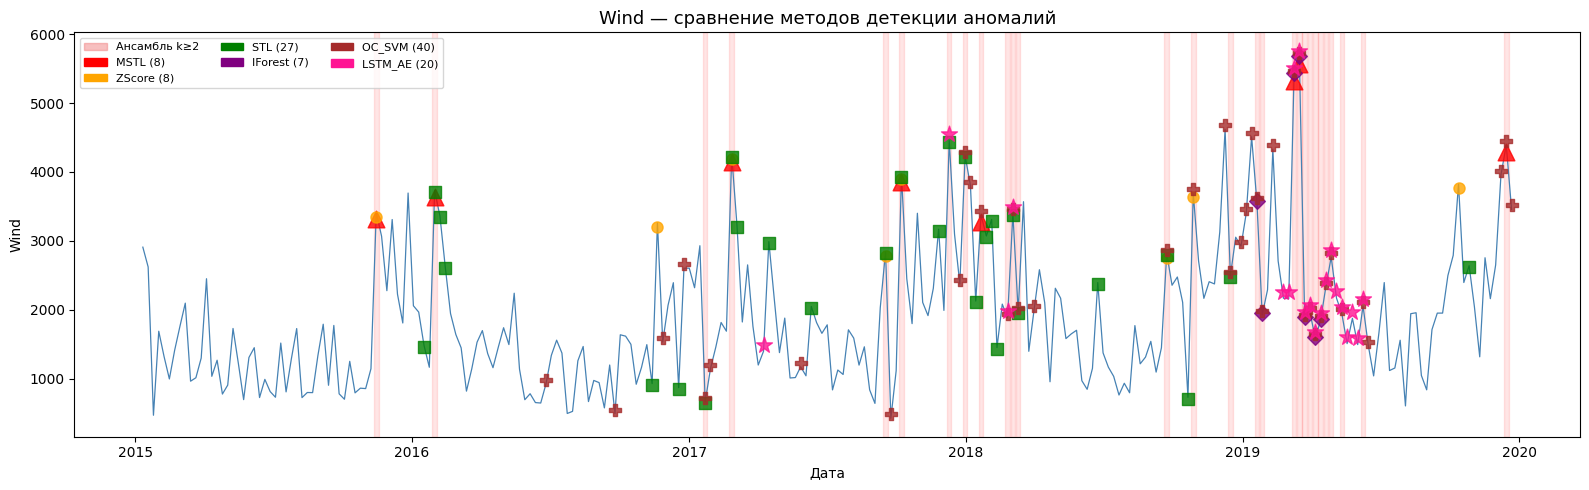

Сохранено: comparison_wind.png


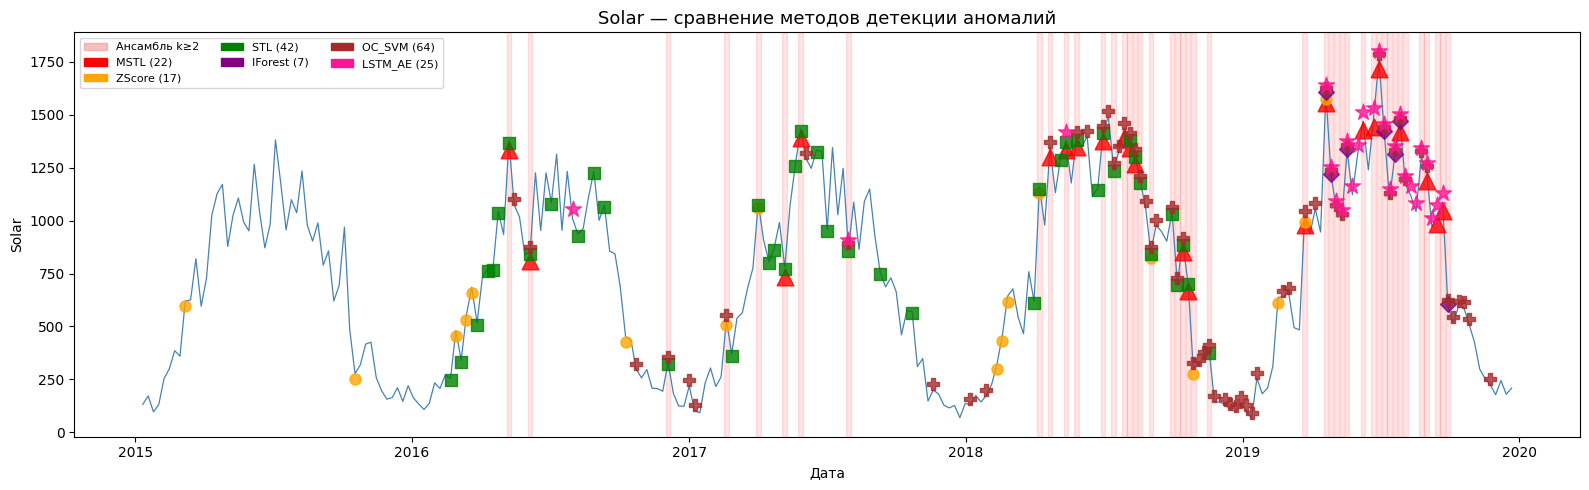

Сохранено: comparison_solar.png


In [17]:
METHOD_COLORS = {
    'MSTL':     ('red',       '^', 12),
    'ZScore':   ('orange',    'o', 8),
    'STL':      ('green',     's', 8),
    'IForest':  ('purple',    'D', 8),
    'OC_SVM':   ('brown',     'P', 8),
    'LSTM_AE':  ('deeppink',  '*', 12),
}

for col in ts:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y[col], lw=0.9, color='steelblue', zorder=1, label='Ряд')

    vote_df = ensemble_results[col]
    # полупрозрачная заливка для ансамблевых аномалий
    for t in y.index[vote_df['ensemble_k2']==1]:
        ax.axvspan(t - pd.Timedelta(days=3), t + pd.Timedelta(days=3),
                   alpha=0.10, color='red', zorder=0)

    handles = [mpatches.Patch(color='lightcoral', alpha=0.5, label='Ансамбль k≥2')]

    # маркеры каждого метода
    offsets = {m: i for i, m in enumerate(methods)}
    for method, (color, marker, ms) in METHOD_COLORS.items():
        s     = all_labels[col][method]
        anom  = y.index[s==1]
        vals  = y.loc[anom, col]
        # небольшой вертикальный сдвиг чтобы маркеры не перекрывались
        shift = (offsets[method] - 2.5) * y[col].std() * 0.04
        ax.scatter(anom, vals + shift,
                   color=color, marker=marker, s=ms**2,
                   zorder=5 + offsets[method], alpha=0.8, label=method)
        handles.append(mpatches.Patch(color=color, label=f'{method} ({len(anom)})'))

    ax.set_title(f'{col} — сравнение методов детекции аномалий', fontsize=13)
    ax.legend(handles=handles, fontsize=8, loc='upper left', ncol=3)
    ax.set_xlabel('Дата')
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.savefig(f'comparison_{col.lower()}.png', dpi=130)
    plt.show()
    print(f"Сохранено: comparison_{col.lower()}.png")

## 10. Задания для студентов

### Обязательные
1. **Настройка порогов.** Для Rolling Z-score попробуйте `threshold = 2.5, 3.0, 3.5`. Как меняется количество аномалий? Постройте таблицу.

2. **Feature importance для Isolation Forest.**  
   ```python
   from sklearn.inspection import permutation_importance
   ```
   Какие признаки наиболее влияют на score?

3. **Стабильность результатов.** Запустите Isolation Forest 5 раз с разными `random_state`. Посчитайте, сколько точек попадают в аномалии при каждом запуске. Есть ли "ядро" устойчивых аномалий?

4. **Интерпретация топ-5 аномалий.** Для каждого ряда найдите 5 наиболее "сильных" аномалий (по количеству методов, которые их обнаружили) и объясните их возможную причину. Проверьте по внешним данным (COVID-19, экстремальные погодные события и т.д.).

### Бонусные
5. Реализуйте **LOF** (Local Outlier Factor) из `sklearn` и добавьте его в ансамбль.

6. Реализуйте **ADTK** (`pip install adtk`) — библиотеку специально для аномалий во временных рядах:
   ```python
   from adtk.detector import SeasonalAD, LevelShiftAD
   ```

7. Попробуйте заменить в LSTM AE `seq_len = 4, 13, 26`. Как меняется чувствительность модели?